In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [38]:
col_names = [
    'age', 'workclass', 'fnlwgt',
    'education', 'education-num', 
    'marital-status', 'occupation', 
    'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 
    'hours-per-week', 'native-country',
    'income' 
]
df_train = pd.read_csv("adult.data.txt", header=None, names=col_names, skipinitialspace=True, na_values='?')
df_test = pd.read_csv("adult/adult.test", header=None, names=col_names, skipinitialspace=True, na_values='?', skiprows=1)

df_test['income'] = df_test['income'].str.rstrip('.')
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

for col in cat_cols:
    le = LabelEncoder().fit(pd.concat([df_train[col], df_test[col]]))
    df_train[col] = le.transform(df_train[col])
    df_test[col] = le.transform(df_test[col])

featured_cols = [c for c in col_names if c != 'income']
X_train = df_train[featured_cols].values
Y_train = (df_train['income'] == '>50K').astype(int).values
X_test = df_test[featured_cols].values
Y_test = (df_test['income'] == '>50K').astype(int).values

In [52]:
def get_metrics(Y, yp, yb):
    return {
        "Error": round(1 - accuracy_score(Y, yp), 4),
        "Accuracy": round(accuracy_score(Y, yp), 4),
        "Precision": round(precision_score(Y, yp, zero_division=0), 4),
        "Recall": round(recall_score(Y, yp, zero_division=0), 4),
        "F1": round(f1_score(Y, yp, zero_division=0), 4),
        "AUC": round(roc_auc_score(Y, yb), 4)
    }

### 1a:

In [53]:
dt_info = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_info.fit(X_train, Y_train)

Y_train_pred = dt_info.predict(X_train)
Y_test_pred = dt_info.predict(X_test)

Y_train_prob = dt_info.predict_proba(X_train)[:, 1]
Y_test_prob = dt_info.predict_proba(X_test)[:, 1]

rows = [
    {"Split": "Train", **get_metrics(Y_train, Y_train_pred, Y_train_prob)},
    {"Split": "Test", **get_metrics(Y_test, Y_test_pred, Y_test_prob)}
]

display(pd.DataFrame(rows).set_index("Split"))

print(f'Nodes: {dt_info.tree_.node_count}')

,Error,Accuracy,Precision,Recall,F1,AUC
Split,,,,,,
Train,0.0000,1.0000,1.0000,0.9999,0.9999,1.0000
Test,0.1906,0.8094,0.6102,0.6205,0.6153,0.7457


Nodes: 8861


### 1b:

In [54]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, Y_train)

Y_train_pred = dt_gini.predict(X_train)
Y_test_pred = dt_gini.predict(X_test)

Y_train_prob = dt_gini.predict_proba(X_train)[:, 1]
Y_test_prob = dt_gini.predict_proba(X_test)[:, 1]

rows = [
    {"Split": "Train", **get_metrics(Y_train, Y_train_pred, Y_train_prob)},
    {"Split": "Test", **get_metrics(Y_test, Y_test_pred, Y_test_prob)}
]

display(pd.DataFrame(rows).set_index("Split"))

print(f'Nodes: {dt_gini.tree_.node_count}')

,Error,Accuracy,Precision,Recall,F1,AUC
Split,,,,,,
Train,0.0000,1.0000,1.0000,0.9999,0.9999,1.0000
Test,0.1988,0.8012,0.5924,0.6116,0.6019,0.7374


Nodes: 9205


### 1c Part 1:

,Max Depth,Train Accuracy,Validation Accuracy,Nodes
0,2,0.7983,0.7921,7
1,4,0.8408,0.8422,27
2,6,0.8496,0.8508,91
3,8,0.8549,0.8555,235
4,10,0.8613,0.8541,499
5,15,0.8983,0.8427,1933
6,20,0.9392,0.8331,3911


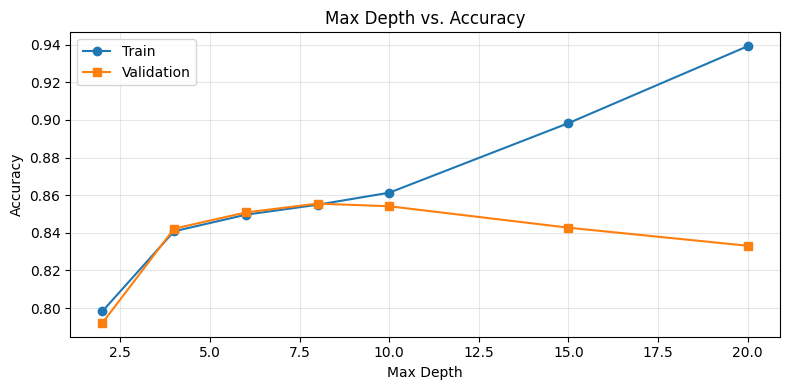

In [67]:
X_tr, X_val, Y_tr, Y_val = train_test_split(
    X_train, Y_train, test_size = 0.2, random_state= 42
)

depths = [2,4,6,8,10,15,20]
train_acc = []
val_acc = []
nodes = []

for d in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    clf.fit(X_tr, Y_tr)

    train_acc.append(round(accuracy_score(Y_tr, clf.predict(X_tr)), 4))
    val_acc.append(round(accuracy_score(Y_val, clf.predict(X_val)), 4))
    nodes.append(clf.tree_.node_count)

df_depth = pd.DataFrame({
    "Max Depth": depths,
    "Train Accuracy": train_acc,
    "Validation Accuracy": val_acc,
    "Nodes": nodes
})
display(df_depth)

plt.figure(figsize=(8,4))
plt.plot(depths, train_acc, 'o-', label="Train")
plt.plot(depths, val_acc, 's-', label = "Validation")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Max Depth vs. Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1c Part 2:

,Min Samples Leaf,Train Accuracy,Validation Accuracy,Nodes
0,1,1.0000,0.8092,7147
1,2,0.9638,0.8124,6091
2,5,0.9160,0.8253,3561
3,10,0.8893,0.8371,2103
4,20,0.8733,0.8463,1193
5,50,0.8616,0.8510,563


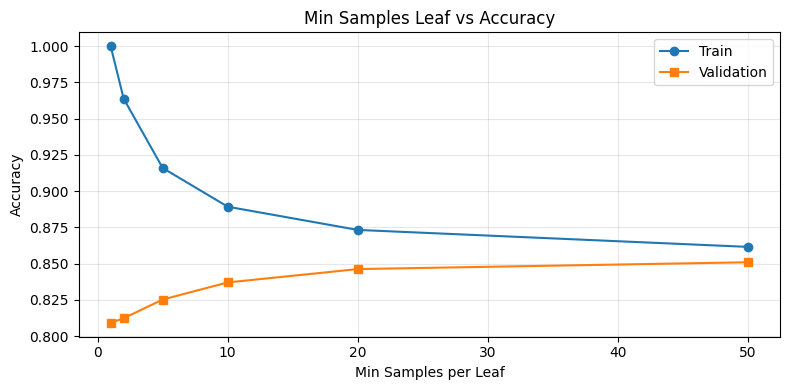

In [68]:
leaf_sizes = [1, 2, 5, 10, 20, 50]

train_acc = []
val_acc = []
nodes = []

for m in leaf_sizes:
    clf = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=m, random_state=42)
    clf.fit(X_tr, Y_tr)

    train_acc.append(round(accuracy_score(Y_tr, clf.predict(X_tr)), 4))
    val_acc.append(round(accuracy_score(Y_val, clf.predict(X_val)), 4))
    nodes.append(clf.tree_.node_count)

df_leaf = pd.DataFrame({
    "Min Samples Leaf": leaf_sizes,
    "Train Accuracy": train_acc,
    "Validation Accuracy": val_acc,
    "Nodes": nodes
})

display(df_leaf)

plt.figure(figsize=(8,4))
plt.plot(leaf_sizes, train_acc, 'o-', label="Train")
plt.plot(leaf_sizes, val_acc, 's-', label="Validation")

plt.xlabel("Min Samples per Leaf")
plt.ylabel("Accuracy")
plt.title("Min Samples Leaf vs Accuracy")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1c Part 3:

,Alpha,Train Accuracy,Validation Accutacy,Nodes
0,0.0000,1.0000,0.8092,7147
1,0.0001,0.8559,0.8575,111
2,0.0002,0.9681,0.8137,4811
3,0.0005,0.8795,0.8548,613
4,0.0010,0.8353,0.8382,21
5,0.0050,0.8496,0.8513,49


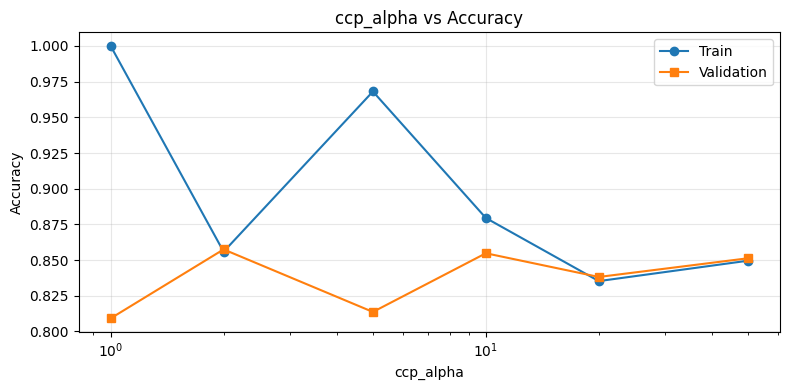

In [71]:
alphas = [0.0,0.0005,0.0001,0.0002,0.005,0.001]

train_acc = []
val_acc = []
nodes = []

for a in alphas:
    clf = DecisionTreeClassifier(criterion='entropy', ccp_alpha=a, random_state=42)
    clf.fit(X_tr, Y_tr)

    train_acc.append(round(accuracy_score(Y_tr, clf.predict(X_tr)), 4))
    val_acc.append(round(accuracy_score(Y_val, clf.predict(X_val)), 4))
    nodes.append(clf.tree_.node_count)

df_ccp = pd.DataFrame({
    "Alpha": sorted(alphas),
    "Train Accuracy": train_acc,
    "Validation Accutacy": val_acc,
    "Nodes": nodes
})

display(df_ccp)

plt.figure(figsize=(8,4))
plt.plot(leaf_sizes, train_acc, 'o-', label="Train")
plt.plot(leaf_sizes, val_acc, 's-', label="Validation")

plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("ccp_alpha vs Accuracy")
plt.xscale('log')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2a:

In [77]:
trees = [10,50,100,500]
rows = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t, random_state = 24, n_jobs = -1)
    rf.fit(X_train, Y_train)
    Y_train_pred = rf.predict(X_train)
    Y_test_pred = rf.predict(X_test)
    Y_train_prob = rf.predict_proba(X_train)[:,1]
    Y_test_prob = rf.predict_proba(X_test)[:,1]

    rows.append({
        "Trees": t,
        **{f"Train{k}": v for k, v in get_metrics(Y_train, Y_train_pred, Y_train_prob).items()},
        **{f"Test {k}": v for k, v in get_metrics(Y_test, Y_test_pred, Y_test_prob).items()}
    })
df_rf = pd.DataFrame(rows)
display(df_rf)

,Trees,TrainError,TrainAccuracy,TrainPrecision,TrainRecall,TrainF1,TrainAUC,Test Error,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,10,0.0130,0.9870,0.9942,0.9532,0.9733,0.9994,0.1564,0.8436,0.7338,0.5705,0.6419,0.8813
1,50,0.0007,0.9993,0.9999,0.9975,0.9987,1.0000,0.1524,0.8476,0.7267,0.6086,0.6625,0.9008
2,100,0.0000,1.0000,1.0000,0.9999,0.9999,1.0000,0.1509,0.8491,0.7282,0.6154,0.6671,0.9029
3,500,0.0000,1.0000,1.0000,0.9999,0.9999,1.0000,0.1498,0.8502,0.7294,0.6205,0.6706,0.9046


### 2c:

,Feature,Importance
2,fnlwgt,0.173242
0,age,0.148904
10,capital-gain,0.114210
7,relationship,0.104922
4,education-num,0.090708
12,hours-per-week,0.082133
5,marital-status,0.069538
6,occupation,0.067233
1,workclass,0.038739
11,capital-loss,0.036092


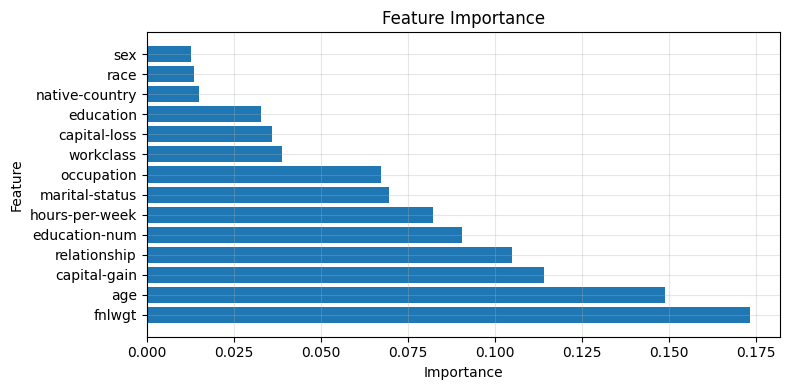

In [81]:
rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train, Y_train)
features = featured_cols
importance = rf.feature_importances_

df_imp = pd.DataFrame({
    "Feature": features, 
    "Importance": importance,
}).sort_values(by="Importance", ascending=False)
display(df_imp)

plt.figure(figsize=(8,4))
plt.barh(df_imp["Feature"], df_imp["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3a:

In [87]:
tree_values = [10,50,100,500]
rows_ada = []
rows_gb = []

for t in tree_values:
    base = DecisionTreeClassifier(max_depth=3,random_state=42)
    ada = AdaBoostClassifier(
        estimator=base,
        n_estimators=t,
        learning_rate=0.1,
        random_state=42
    )
    ada.fit(X_train,Y_train)
    Y_train_pred = ada.predict(X_train)
    Y_test_pred = ada.predict(X_test)
    Y_train_prob = ada.predict_proba(X_train)[:,1]
    Y_test_prob = ada.predict_proba(X_test)[:,1]

    rows_ada.append({
        "Trees": t,
        **{f"Train {k}": v for k, v in get_metrics(Y_train, Y_train_pred,Y_train_prob).items()},
        **{f"Test {k}": v for k, v in get_metrics(Y_test, Y_test_pred, Y_test_prob).items()}

    })

    gb = GradientBoostingClassifier(
        n_estimators=t,
        learning_rate = 0.1,
        max_depth=3,
        random_state=42
    )
    gb.fit(X_train, Y_train)

    Y_train_pred = gb.predict(X_train)
    Y_test_pred = gb.predict(X_test)
    Y_train_prob = gb.predict_proba(X_train)[:,1]
    Y_test_prob = gb.predict_proba(X_test)[:,1]

    rows_gb.append({
        "Trees": t,
        **{f"Train {k}": v for k, v in get_metrics(Y_train, Y_train_pred,Y_train_prob).items()},
        **{f"Test {k}": v for k, v in get_metrics(Y_test, Y_test_pred, Y_test_prob).items()}
    })
    df_ada = pd.DataFrame(rows_ada)
    df_gb = pd.DataFrame(rows_gb)

    print("AdaBoost Results")
    display(df_ada)
    print("Gradient Boosting Results")
    display(df_gb)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Results


,Trees,Train Error,Train Accuracy,Train Precision,Train Recall,Train F1,Train AUC,Test Error,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,10,0.1605,0.8395,0.7884,0.4853,0.6008,0.8925,0.1627,0.8373,0.7768,0.4741,0.5888,0.8906


Gradient Boosting Results


,Trees,Train Error,Train Accuracy,Train Precision,Train Recall,Train F1,Train AUC,Test Error,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,10,0.1632,0.8368,0.8315,0.4319,0.5685,0.8884,0.1641,0.8359,0.8222,0.4238,0.5593,0.8882


...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Results


,Trees,Train Error,Train Accuracy,Train Precision,Train Recall,Train F1,Train AUC,Test Error,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,10,0.1605,0.8395,0.7884,0.4853,0.6008,0.8925,0.1627,0.8373,0.7768,0.4741,0.5888,0.8906
1,50,0.1382,0.8618,0.8214,0.5683,0.6718,0.9246,0.1387,0.8613,0.8128,0.5657,0.6671,0.9215
2,100,0.1290,0.8710,0.8045,0.6363,0.7105,0.9314,0.1315,0.8685,0.7915,0.6311,0.7023,0.9260
3,500,0.1133,0.8867,0.8190,0.6995,0.7545,0.9472,0.1309,0.8691,0.7740,0.6600,0.7125,0.9226


Gradient Boosting Results


,Trees,Train Error,Train Accuracy,Train Precision,Train Recall,Train F1,Train AUC,Test Error,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,10,0.1632,0.8368,0.8315,0.4319,0.5685,0.8884,0.1641,0.8359,0.8222,0.4238,0.5593,0.8882
1,50,0.1446,0.8554,0.8092,0.5486,0.6539,0.9144,0.1446,0.8554,0.8008,0.5476,0.6504,0.9112
2,100,0.1361,0.8639,0.7960,0.6092,0.6902,0.9230,0.1371,0.8629,0.7882,0.6046,0.6843,0.9183
3,500,0.1152,0.8848,0.8212,0.6865,0.7478,0.9413,0.1293,0.8707,0.7808,0.6586,0.7146,0.9259


### 3c:

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


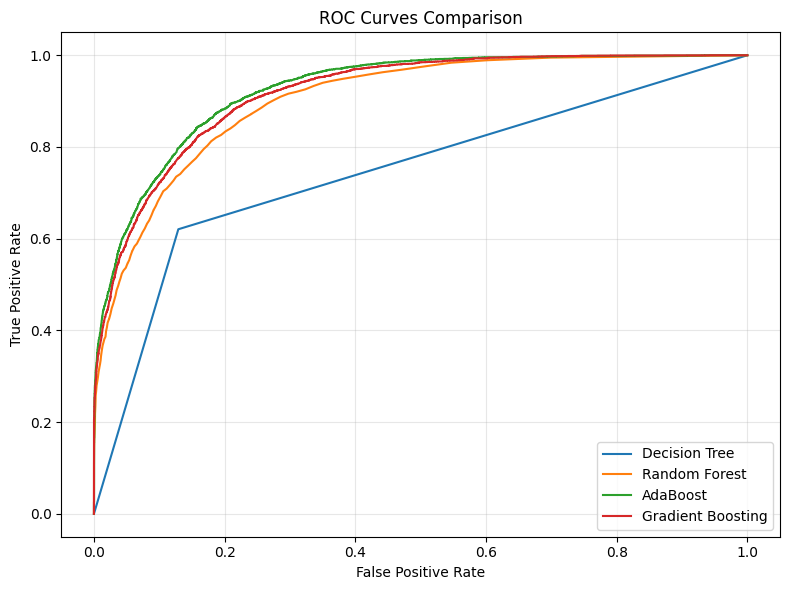

In [92]:
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, Y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, Y_train)

base = DecisionTreeClassifier(max_depth = 3, random_state=42)
ada = AdaBoostClassifier(estimator=base, n_estimators=100, learning_rate=0.1, random_state=42)
ada.fit(X_train,Y_train)
gb = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3, random_state=42)
gb.fit(X_train,Y_train)

dt_prob = dt_prob = dt.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
ada_prob = ada.predict_proba(X_test)[:,1]
gb_prob = gb.predict_proba(X_test)[:,1]

fpr_dt, tpr_dt, _ = roc_curve(Y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(Y_test, rf_prob)
fpr_ada, tpr_ada, _ = roc_curve(Y_test, ada_prob)
fpr_gb, tpr_gb, _ = roc_curve(Y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_ada, tpr_ada, label="AdaBoost")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
df_mushroom = pd.read_csv("mushroom/agaricus-lepiota.data", header=None)

Y_mushroom = df_mushroom[0].values
X_mushroom = df_mushroom.iloc[:,1:].values
X_tr, X_te, Y_tr, Y_te = train_test_split(
    X_mushroom, Y_mushroom, test_size=0.25, random_state=42
)

print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

Train: (6093, 22), Test: (2031, 22)


### 4a:

In [97]:
classes = np.unique(Y_tr)
priors = {}
for c in classes:
    priors[c] = np.mean(Y_tr == c)
print("Priors:", priors)

cond_probs = {}
n_features = X_tr.shape[1]
for j in range(n_features):
    cond_probs[j] = {}
    values = np.unique(X_tr[:,j])
    for c in classes:
        cond_probs[j][c] = {}
        subset = X_tr[Y_tr == c]
        total = subset.shape[0]

        for v in values:
            count = np.sum(subset[:,j] == v)
            cond_probs[j][c][v] = (count+1)/(total + len(values))

Priors: {'e': np.float64(0.5199409158050221), 'p': np.float64(0.48005908419497784)}


### 4b:

In [99]:
test_probs = []
for i in range(X_te.shape[0]):
    X = X_te[i]
    class_probs = {}
    for c in classes:
        log_prob = np.log(priors[c])

        for j in range(n_features):
            v = X[j]

            if v in cond_probs[j][c]:
                log_prob += np.log(cond_probs[j][c][v])
            else:
                log_prob += np.log(1e-6)
        class_probs[c] = log_prob
    max_log = max(class_probs.values())

    exp_probs = {}
    total = 0

    for c in classes:
        exp_probs[c] = np.exp(class_probs[c] - max_log)
        total += exp_probs[c]
    
    probs = {}
    for c in classes:
        probs[c] = exp_probs[c] / total
    test_probs.append(probs)
print(test_probs[:5])
    


[{'e': np.float64(0.999992814171691), 'p': np.float64(7.185828309009528e-06)}, {'e': np.float64(1.8710211587340255e-10), 'p': np.float64(0.9999999998128979)}, {'e': np.float64(8.971446190655144e-12), 'p': np.float64(0.9999999999910285)}, {'e': np.float64(0.9999999831229532), 'p': np.float64(1.68770468052492e-08)}, {'e': np.float64(1.7863595678561978e-10), 'p': np.float64(0.999999999821364)}]


### 4c:

In [100]:
Y_pred = []

for probs in test_probs:
    if probs['e'] > probs['p']:
        Y_pred.append('e')
    else:
        Y_pred.append('p')
Y_pred = np.array(Y_pred)

TP = 0
TN = 0
FP = 0
FN = 0

for i in range(len(Y_te)):
    if Y_te[i] == 'p' and Y_pred[i] == 'p':
        TP += 1
    elif Y_te[i] == 'e' and Y_pred[i] == 'e':
        TN += 1
    elif Y_te[i] == 'e' and Y_pred[i] == 'p':
        FP +=1
    elif Y_te[i] == 'p' and Y_pred[i] == 'e':
        FN += 1

accuracy = (TP + TN) / len(Y_te)
precision = TP / (TP+FP)
recall = TP / (TP+FN)
f1 = 2 * precision * recall / (precision + recall)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9487936976858691
Precision: 0.9900552486187846
Recall: 0.9041372351160444
F1 Score: 0.9451476793248945


### 4d:

In [108]:
encoder = OrdinalEncoder()

X_tr_enc = encoder.fit_transform(X_tr)
X_te_enc = encoder.transform(X_te)

Y_tr_bin = (Y_tr == 'p').astype(int)
Y_te_bin = (Y_te == 'p').astype(int)

nb = CategoricalNB()
nb.fit(X_tr_enc, Y_tr_bin)

Y_pred_nb = nb.predict(X_te_enc)

accuracy_nb = accuracy_score(Y_te_bin, Y_pred_nb)
precision_nb = precision_score(Y_te_bin, Y_pred_nb)
recall_nb = recall_score(Y_te_bin, Y_pred_nb)
f1_nb = f1_score(Y_te_bin, Y_pred_nb)

print("Accuracy:", accuracy_nb)
print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1 Score:", f1_nb)

Accuracy: 0.9487936976858691
Precision: 0.9900552486187846
Recall: 0.9041372351160444
F1 Score: 0.9451476793248945
